In [19]:
from asyncio import PriorityQueue

from numpy import Infinity
from prompt_toolkit.styles import Priority


class Vertex():
    def __init__(self,key):
        self.id = key
        self.connectionTo = {}
        self.predecessor = None#在使用bfs，dfs，最短路径以及最小生成树时被用到。
        self.color = "white"
        self.distance = 0

    def getId(self):
        return self.id

    def __str__(self):
        return str(self.id) +"is connected to:"+str([x.id for x in self.connectionTo])#遍历所有的键值

    def addNeighbor(self,key,weight=0):
        self.connectionTo[key] = weight

    def getConnectionTo(self,key):
        return self.connectionTo.keys()#获取所有的键值

    def getWeight(self,key):
        return self.connectionTo[key]

class Graph():
    def __init__(self):
        self.nodelist = {}
        self.number_of_nodes = 0

    def add_vertex(self,key):
        self.number_of_nodes += 1
        vertex = Vertex(key)
        self.nodelist[key] = vertex

    def add_edge(self,start,end,weight=0):
        if start not in self.nodelist:
            self.add_vertex(start)
        if end not in self.nodelist:
            self.add_vertex(end)
        self.nodelist[start].addNeighbor(self.nodelist[end],weight)

    def get_vertex(self,key):
        if key not in self.nodelist:
            return None
        else:
            return self.nodelist[key]

    def get_vertices(self):
        return self.nodelist.keys()#返回图中所有的顶点

    def __iter__(self):
        return iter(self.nodelist.values())

    def __contains__(self,key):
        return key in self.nodelist

对于顶点这个类而言，有两个最为重要的成员变量，一个是顶点的ID，另一个是顶点所连接的其他顶点的字典，这个字典的键就是所连接的节点，值对应连接的权重。

而对于图这个类而言，也有一个字典，这个字典的键代表着顶点的序号，值代表着顶点对象。

而对于一个字典而言，dict.keys()意思是取出这个字典所有的键，for i in dict的意思是对字典的所有键进行遍历

In [20]:
class Queue:
    def __init__(self):
        self.items=[]
        self.front=0

    def enqueue(self,item):
        self.items.append(item)

    def dequeue(self):
        return self.items.pop(0)

    def isEmpty(self):
        return not self.items

    def peek(self):
        return self.items[self.front]

    def __len__(self):
        return len(self.items)

词梯问题：

In [21]:
def buildGraph(wordfile):
    graph = Graph()
    dict= {}
    words = open(wordfile,'r')
    for line in words:
        word = line[-1]
        for i in range(len(word)):
            bucket = word[:i] +"_"+ word[i+1:]
            if bucket in dict.keys():
                dict[bucket].append(word)
            else:
                dict[bucket] = [word]

    for i in range(dict.keys()):
        for j in dict[i]:
            for k in dict[i]:
                if j!=k:
                    graph.add_edge(j,k,weight=1)
    return graph

排序算法：BFS算法的时间复杂度为O(V+E)

In [22]:
def bfs(graph, start):
    queue = Queue()
    queue.enqueue(start)
    while len(queue) > 0:
        vertex = queue.dequeue()
        for neighbor in vertex.connectionTo.keys():
            if neighbor.color == "white":
                neighbor.predecessor = vertex
                neighbor.distance = vertex.distance + 1
                neighbor.color = "gray"
                queue.enqueue(neighbor)
        vertex.color = "black"

def traverse(x, y):
    while x.predecessor:
        print(x.id)
        x = x.predecessor
    print(x.id)

骑士周游问题

In [39]:
def general_legal_position(x,y,bdsize):
    list = []
    offset = [(1,2),(2,1),(-1,-2),(-2,-1),
              (1,-2),(-2,1),(-1,2),(2,-1)]
    for i in offset:
        new_x = x + i[0]
        new_y = y + i[1]
        if detect(new_x,new_y,bdsize):
            list.append((new_x,new_y))
    return list

def detect(x,y,bdsize):
    if 0<=x<bdsize and 0<=y<bdsize:
        return True
    else:
        return False

def link_vertex(bdsize):
    graph = Graph()
    for x in range(bdsize):
        for y in range(bdsize):
            vertex_list = general_legal_position(x,y,bdsize)
            for i in vertex_list:
                graph.add_edge((x,y),(i[0],i[1]))
    return graph

def knight_tour(n,path,limit,vertex):#如果done为false的话，会一直在循环里直到遍历完所有可以到达的节点，最后返回失败，表示无法遍历完，否则的话最终在遍历最后一个结点的时候会返回true，最终回到最开始调用函数的地方，结束函数的调用。
    vertex.color = "gray"
    path.append(vertex)
    if n < limit:
        nbr = vertex_prefer(vertex)
        i = 0
        done = False
        while i < len(nbr) and not done:
            if nbr[i].color == "white":
                done = knight_tour(n+1,path,limit,nbr[i])
            i = i + 1
        if not done:
            path.pop()
            vertex.color = "white"
    else:
        done = True
    return done

def vertex_prefer(node):
    list=[]
    for x in node.connectionTo.keys():
        if x.color == "white":
            c=0
            for v in x.connectionTo.keys():
                if v.color == "white":
                    c=c+1
            list.append((c,x))
    list.sort(key=lambda x:x[0])
    return [x[1] for x in list]



In [40]:
graph = link_vertex(64)
# print(graph.nodelist[(63,62)])
knight_tour(0,[],63,graph.nodelist[(5,0)])

True

In [ ]:
def dfs(graph):
    for x in graph.nodelist:
        x.color = "white"
        x.predecessor = -1
    for i in graph.nodelist:
        if i.color == "white":
            dfs_visit(i,graph)

def dfs_visit(vertex,graph):
    vertex.color = "grey"
    for x in vertex.connectionTo.keys():
        if x.color == "white":
            x.predecessor = vertex
            dfs_visit(x,graph)
    vertex.color = "black"



BFS采用队列存储待访问顶点

DFS则是通过递归调用，隐式使用了栈

一个连通图的生成树是一个极小的连通子图，它含有图中全部的顶点，但只有足以构成一棵树的n − 1条边，若砍去它的一条边，则会使生成树变成非连通图；若给它增加一条边，则会形成图中的一条回路。对于一个带权连通无向图G = ( V , E )，生成树不同，其中边的权值之和最小的那棵生成树（构造连通网的最小代价生成树），称为G的最小生成树(Minimum-Spanning-Tree, MST)。

最小生成树算法：从一个顶点出发，在保证不形成回路的前提下，每找到并添加一条最短的边，就把当前形成的连通分量当做一个整体或者一个点看待，然后重复“找最短的边并添加”的操作。

处理的是无向加权连通图

普利姆算法：处理的是点

In [ ]:
def MiniSpanTree_Prim(G):
    cost = [Infinity]*len(G)
    cost[0]=0 #对于普利姆算法而言，cost代表着每个顶点到当前连通分量的最小值。
    for i in G.nodelist[0].connectionTo:
        cost[i.id] = G.nodelist[0].connectionTo[i]

    for i in range(1,len(G)):
        cost = Infinity
        j = 1
        k = 0
        while j < len(G.node_number):
            if cost[j]<cost and cost[j]:
                cost = cost[j]
                k = j
            j = j+1

        cost[k]=0
        for z in G.nodelist[k].connectionTo:
            if cost[z] and G.nodelist[k].connectionTo[z]<cost[z]:
                cost[z] = G.nodelist[k].connectionTo[z]
                z.predecessor = k

克鲁斯卡尔算法：使用了并查集数据结构，处理的是边

In [ ]:
class Graph:
    def __init__(self, vertices):
        self.V = vertices  # 顶点数
        self.graph = []    # 存储所有边的列表

    def add_edge(self, u, v, w):
        """添加边(u, v)，权重为w"""
        self.graph.append((u, v, w))

    def find(self, parent, i):
        """查找元素i的根节点（使用路径压缩）"""
        if parent[i] != i:
            parent[i] = self.find(parent, parent[i])
        return parent[i]

    def union(self, parent, rank, x, y):
        """按秩合并两个集合"""
        root_x = self.find(parent, x)
        root_y = self.find(parent, y)

        if rank[root_x] < rank[root_y]:
            parent[root_x] = root_y
        elif rank[root_x] > rank[root_y]:
            parent[root_y] = root_x
        else:
            parent[root_y] = root_x
            rank[root_x] += 1

    def Krustral(self):
        parent = []#位置代表元素，位置上的值代表顶点的父节点
        rank = []
        result =[]
        for i in self.V:
            parent.append(i)
            rank.append(0)

        self.graph.sort(key=lambda x:x[2])
        edges_in_mst = 0  # MST中的边数

        # MST应有V-1条边
        while edges_in_mst < self.V - 1:#循环退出代表着已收集够self.v-1条边。
            # 步骤2：选择最小权重的边
            u, v, w = self.graph[i]
            i += 1

            root_u = self.find(parent, u)
            root_v = self.find(parent, v)

            # 如果u和v不在同一集合，则加入MST
            if root_u != root_v:
                edges_in_mst += 1
                result.append((u, v, w))
                self.union(parent, rank, root_u, root_v)

        return result



最短路径问题：

1.迪杰斯特拉算法

2.佛洛依德算法

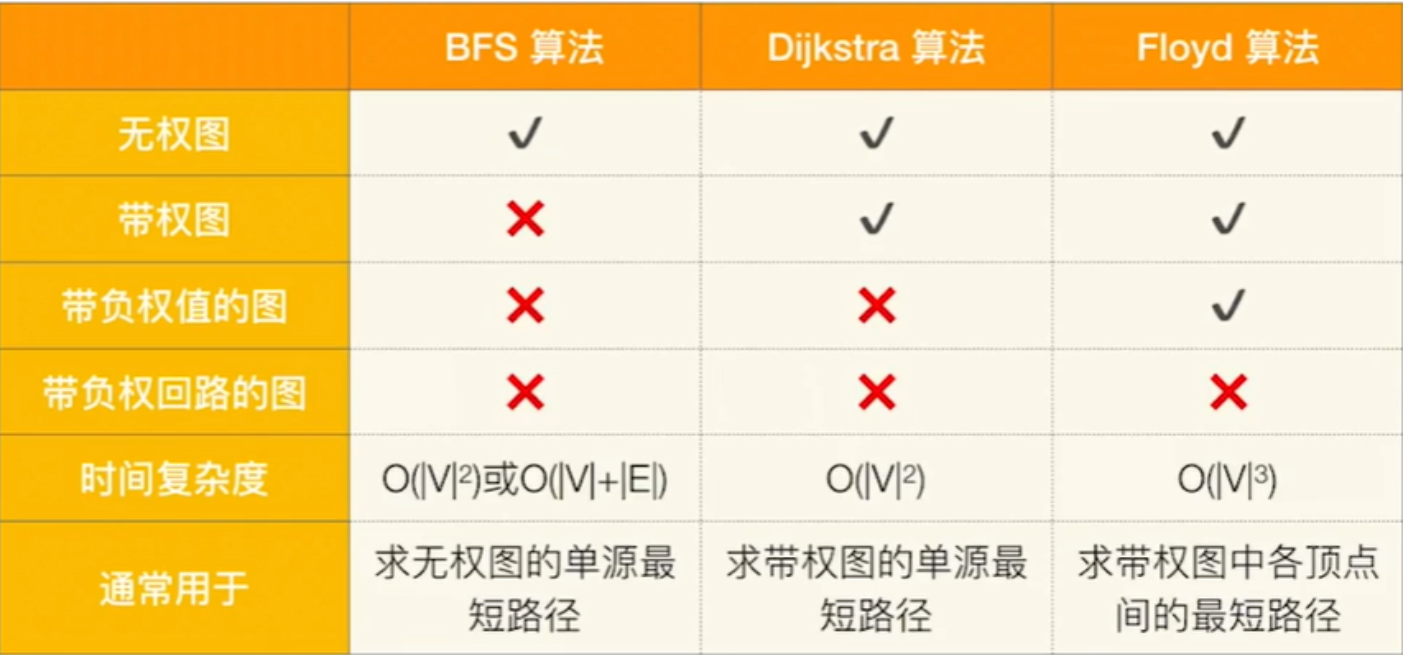

迪杰斯特拉算法代码实现：

在迪杰斯特拉算法中，对于一个含有n个节点的加权图而言，每次循环只负责取出带价值最小的节点加入到路径中，然后更改其他节点的最小路径，因此需要n次循环。

In [ ]:
def dijkstra(graph,start):
    start.setDistance(0)
    pq = PriorityQueue()
    pq.buildHeap((v.distance,v) for v in graph.nodelist)
    while not pq.isEmpty():
        current = pq.delMin()
        for nextvertex in current.connectionTo:
            newdis = current.distance + current.connectionTo[nextvertex]
            if newdis < nextvertex.distance:
                nextvertex.distance = newdis
                nextvertex.predecessor = current
                pq.decrease(nextvertex.distance,nextvertex)

In [ ]:
def dijkstra_1(graph,start):
    cost = [Infinity]*graph.number_of_nodes
    parent = [None]*graph.number_of_nodes
    cost[start]=0
    parent[start]=0
    visited = [False]*graph.number_of_nodes
    min_vertex = start
    for _ in range(graph.number_of_nodes):
        min_cost = Infinity
        for i in range(graph.number_of_nodes):
            if not visited[i] and cost[i] < min_cost:#迪杰斯特拉算法的代价指的是从该节点到开始结点的代价
                min_cost = cost[i]
                min_vertex = i

        visited[min_vertex] = True
        for i in graph.nodelist[min_vertex].connectionTo:
            newcost = cost[min_vertex] + graph.nodelist[min_vertex.connectionTo[i]]
            if cost[i.id] > newcost:
                cost[i.id] = newcost
                parent[i.id] = min_vertex

    return cost, parent



**拓扑排序算法：**（时间复杂度为O(V+E)） 不能有环

方法一：入度出度算法

方法二：DFS算法

Aov网络：用顶点表示活动，用弧表示活动之间的优先关系

DAG图（有向无环图）

In [1]:
from collections import deque, defaultdict#入度出度算法

def topological_sort_kahn(graph):
    """
    使用Kahn算法进行拓扑排序
    :param graph: 邻接表表示的图，{node: [neighbors]}
    :return: 拓扑排序结果，如果图有环则返回None
    """
    # 计算所有节点的入度
    in_degree = defaultdict(int)
    for node in graph:
        for neighbor in graph[node]:
            in_degree[neighbor] += 1
        # 确保所有节点都在in_degree中（包括入度为0的节点）
        if node not in in_degree:
            in_degree[node] = 0

    # 初始化队列，将所有入度为0的节点加入队列
    queue = deque([node for node in in_degree if in_degree[node] == 0])
    result = []

    while queue:
        # 取出入度为0的节点
        current = queue.popleft()
        result.append(current)

        # 遍历当前节点的所有邻居
        for neighbor in graph.get(current, []):
            # 减少邻居的入度
            in_degree[neighbor] -= 1
            # 如果邻居的入度变为0，加入队列
            if in_degree[neighbor] == 0:
                queue.append(neighbor)

    # 检查是否有环
    if len(result) == len(in_degree):
        return result
    else:
        return None  # 图中有环，无法进行拓扑排序

关键路径：

AOV网络：顶点表示事件，以有向边表示活动，以边上的权值表示完成该活动的开销(如完成活动所需的时间)

AOV网络与AOE网络都是有向无环图，AOV网络边有权重，AOV无，仅代表活动之间的先后关系

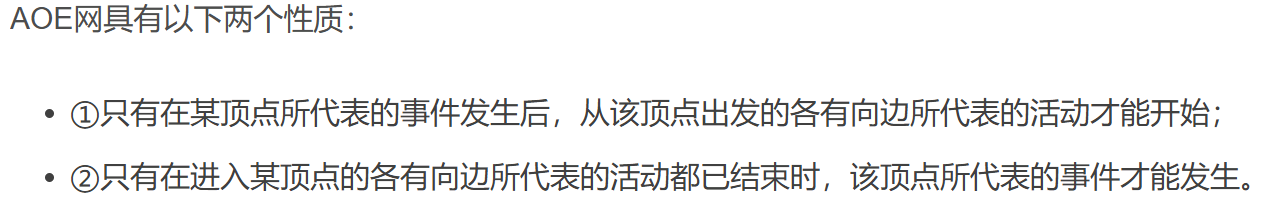

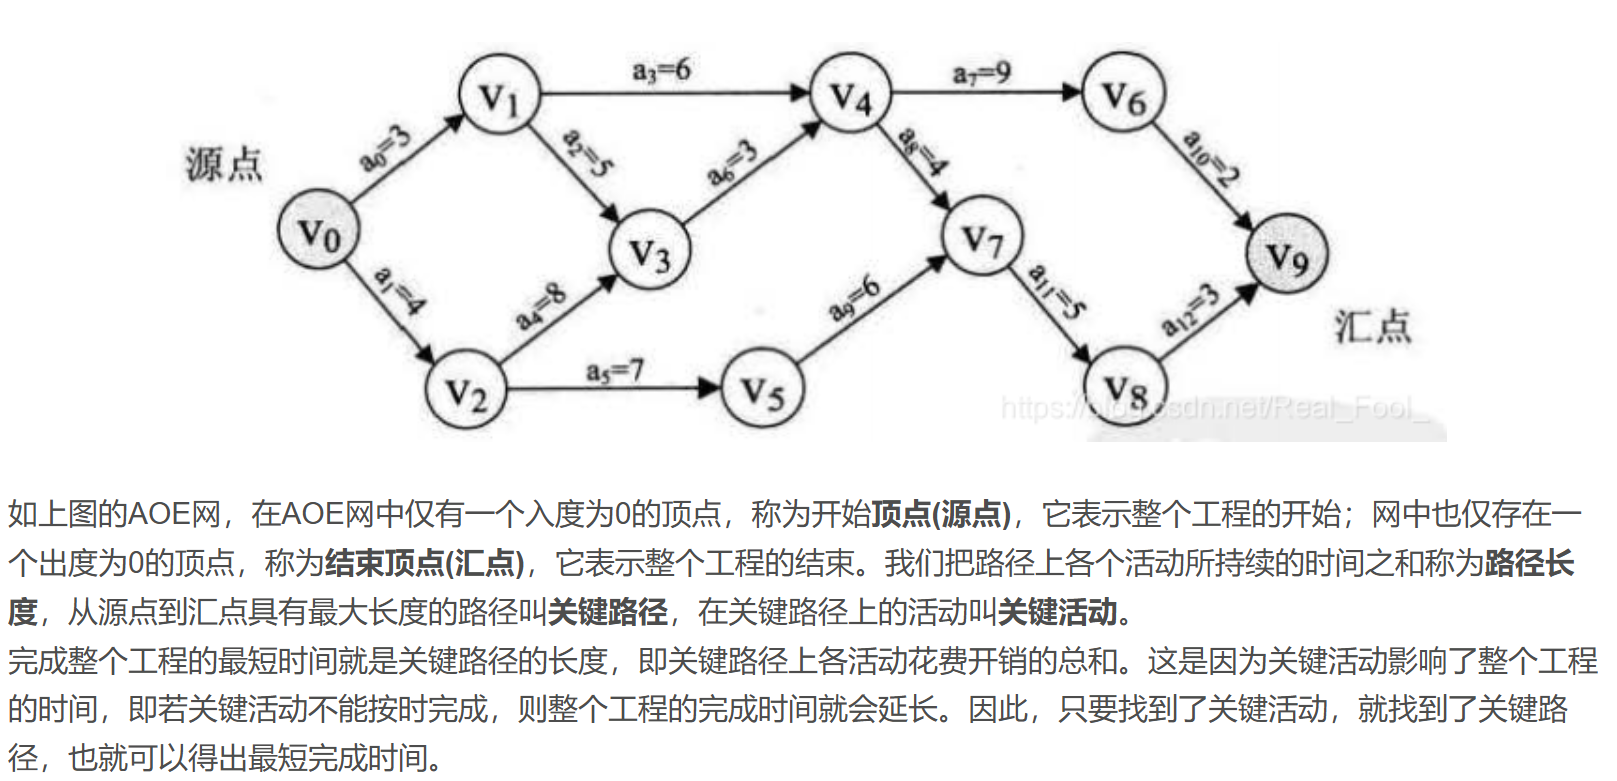

先使用拓扑排序算法求出每个事件的最早开始时间，在使用逆拓扑排序算法求出每个事件的最晚开始时间，

拓扑排序算法：设置所有点的最早开始时间为0，依次找到入度为0的顶点，删去顶点以及和它所连接的出边，比较当前点的最早开始时间加上出边的时间是否比子顶点当前的最早开始时间大，大证明更加耗费时间，更新其他点的最早开始时间。

逆拓扑排序算法：设置所有点的最晚开始时间为汇点的最早开始时间，依次找到出度为0的顶点，删去顶点以及和它所连接的入边，比较当前点的最晚开始时间减去入边的时间是否比子顶点当前的最晚开始时间小，更新其他点的最早开始时间。

而对于一个活动（边）而言，最早开始时间就是箭尾对应的事件的最早开始时间，最晚开始时间是箭头所指的事件的最晚开始时间减去活动耗费的时间。最早开始时间与最晚开始时间相同的活动就是关键活动。